# «Что происходит с лекарством в нашем организме?» ADME?
*   Absorption - передачи лекарственного препарата от места введения к месту действия
*   Distribution - распределение лекарственного средства между тканями
*   Metabolism - расщепление (только часть препарата достигнет цели)
*   Excretion - соединения и их метаболиты должны выводиться из организма. Неполное выведение может привести к их накоплению и возможным негативным последствиям.

**Правило пяти Липински (RO5)**— это **эмпирическое** правило для оценки сходства с лекарством или определения того, обладает ли химическое соединение с определенной фармакологической или биологической активностью, химическими свойствами и физическими свойствами, которые могут сделать его перорально активным препаратом для человека. **Биодоступность**

* Молекулярная масса (MWT) <= 500 Да
* Количество акцепторов водородных связей (HBA) <= 10
* Количество доноров водородных связей (HBD) <= 5
* Рассчитанный LogP (коэффициент октанол-вода) <= 5

**Правило не предсказывает, является ли соединение фармакологически активным.**

**Пример 1: Определить какие из соединений нарушают Правило Пяти Лепински (RO5)**

Соединения:

1.  **Cyclosporine**
CCC1C(=O)N(CC(=O)N(C(C(=O)NC(C(=O)N(C(C(=O)NC(C(=O)NC(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N1)C(C(C)CC=CC)O)C)C(C)C)C)CC(C)C)C)CC(C)C)C)C)C)CC(C)C)C)C(C)C)CC(C)C)C)C

2.  **Clozapine**
CN1CCN(CC1)C2=C3C=CC=CC3=NC4=C(N2)C=C(C=C4)C

3. **Beta-carotene**
CC1=C(C(CCC1)(C)C)C=CC(=CC=CC(=CC=CC=C(C)C=CC=C(C)C=CC2=C(CCCC2(C)C)C)C)C

2. **Cannabidiol**
CCCCCC1=CC(=C(C(=C1)O)C2C=C(CCC2C(=C)C)C)O

**Команды:**
1.  df = pd.DataFrame({'name': names, 'smiles': smiles})
2. PandasTools.AddMoleculeColumnToFrame(df, 'smiles')
3. df['MW'] = molecules['ROMol'].apply(Descriptors.ExactMolWt)  
*   apply(Descriptors.NumHAcceptors)
*   apply(Descriptors.NumHDonors)
*   apply(Descriptors.MolLogP)

4. molecule = Chem.MolFromSmiles(smiles)
*   Descriptors.ExactMolWt(molecule)
*   Descriptors.NumHAcceptors(molecule)
*   Descriptors.NumHDonors(molecule)
*   Descriptors.MolLogP(molecule)


#Установка библиотек

In [ ]:
# Установка библиотеки rdkit
! pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.8/32.8 MB 13.7 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, PandasTools
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

In [ ]:
names = ["m6A","Hesperidin", "Quercetin", "Kaempferol","Rutin"]
smiles = ["n2c1c(ncnc1NC)n(c2)[C@@H]3O[C@@H]([C@@H](O)[C@H]3O)CO","O=C4c5c(O)cc(O[C@@H]2O[C@H](CO[C@@H]1O[C@H]([C@H](O)[C@@H](O)[C@H]1O)C)[C@@H](O)[C@H](O)[C@H]2O)cc5O[C@H](c3ccc(OC)c(O)c3)C4", "O=C1c3c(O/C(=C1/O)c2ccc(O)c(O)c2)cc(O)cc3O", "O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12", "CC1C(C(C(C(O1)OCC2C(C(C(C(O2)OC3=C(OC4=CC(=CC(=C4C3=O)O)O)C5=CC(=C(C=C5)O)O)O)O)O)O)O)O"]

In [ ]:
molecules = pd.DataFrame({'name': names, 'smiles': smiles})

In [ ]:
PandasTools.AddMoleculeColumnToFrame(molecules, 'smiles')

,name,smiles,ROMol
0,m6A,n2c1c(ncnc1NC)n(c2)[C@@H]3O[C@@H]([C@@H](O)[C@...,
1,Hesperidin,O=C4c5c(O)cc(O[C@@H]2O[C@H](CO[C@@H]1O[C@H]([C...,
2,Quercetin,O=C1c3c(O/C(=C1/O)c2ccc(O)c(O)c2)cc(O)cc3O,
3,Kaempferol,O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12,
4,Rutin,CC1C(C(C(C(O1)OCC2C(C(C(C(O2)OC3=C(OC4=CC(=CC(...,

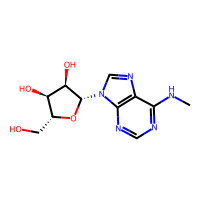
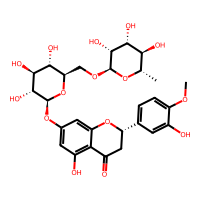
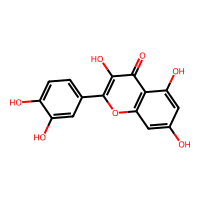
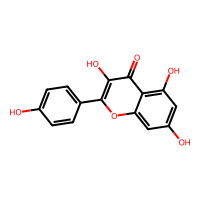
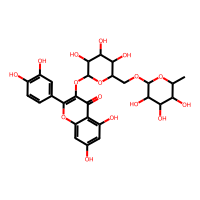

In [ ]:
molecules

In [ ]:
molecules['MW'] = molecules['ROMol'].apply(Descriptors.ExactMolWt)
molecules['HBA'] = molecules['ROMol'].apply(Descriptors.NumHAcceptors)
molecules['HBD'] = molecules['ROMol'].apply(Descriptors.NumHDonors)
molecules['LogP'] = molecules['ROMol'].apply(Descriptors.MolLogP)

,name,smiles,ROMol,MW,HBA,HBD,LogP
0,m6A,n2c1c(ncnc1NC)n(c2)[C@@H]3O[C@@H]([C@@H](O)[C@...,,281.112404,9,4,-1.5205
1,Hesperidin,O=C4c5c(O)cc(O[C@@H]2O[C@H](CO[C@@H]1O[C@H]([C...,,610.189770,15,8,-1.1566
2,Quercetin,O=C1c3c(O/C(=C1/O)c2ccc(O)c(O)c2)cc(O)cc3O,,302.042653,7,5,1.9880
3,Kaempferol,O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12,,286.047738,6,4,2.2824
4,Rutin,CC1C(C(C(C(O1)OCC2C(C(C(C(O2)OC3=C(OC4=CC(=CC(...,,610.153385,16,10,-1.6871

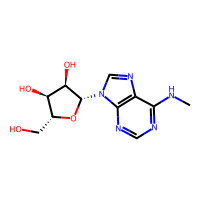
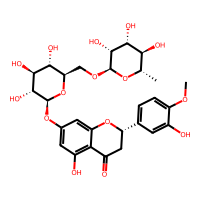
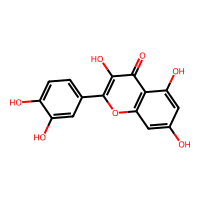
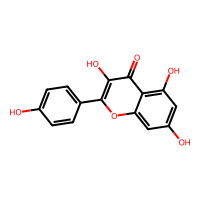
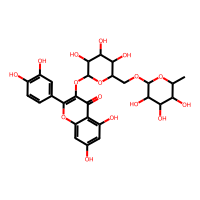

In [ ]:
molecules